In [ ]:
PROJECT_DIR = getwd()
source("feature_construction.R")
source("model_analysis.R")

[1] "Reading in elevation-data buffer"
[1] "Reading in MRLC land-cover raster"


Warning message in prism_dl_dir_check_for_v1(path):
“The specified PRISM download directory appears to have data from the pre September 2025 API.
We recommend either starting a new download directory for the new API and/or
deleting and redownloading all data from the new API.”


[1] "Reading in PRISM Tmean raster"
[1] "Reading in PRISM precip raster"


Rows: 717 Columns: 40
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (3): dominant_nlcd_desc, dominant_eco_group, type
dbl (37): cell, n_checklists, n_detected, det_freq, mean_num_observers, mean...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [2]:
ebird_features_df_pwo <- read_feature_df("features--pile_woodp_2024_us-sc.csv")

Rows: 717 Columns: 40
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (3): dominant_nlcd_desc, dominant_eco_group, type
dbl (37): cell, n_checklists, n_detected, det_freq, mean_num_observers, mean...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [ ]:
# Data structure
cols <- c("cell", "cell_ctr_lat", "cell_ctr_lon", "n_checklists", "n_detected", "det_freq", "mean_num_observers", "mean_start_time_hr", "med_duration", "mean_dist_km", "dist_to_coast_mi", "elevation_ft", "dominant_eco_group", "tmean_2024_C", "ppt_2024_mm")
str(ebird_features_df_pwo[cols])

tibble [717 × 15] (S3: tbl_df/tbl/data.frame)
 $ cell              : num [1:717] 493475 493476 493477 493478 493479 ...
 $ cell_ctr_lat      : num [1:717] 35.1 35.1 35.2 35.2 35.2 ...
 $ cell_ctr_lon      : num [1:717] -82.8 -82.7 -82.5 -82.4 -82.3 ...
 $ n_checklists      : int [1:717] 1 11 180 20 10 2 35 5 15 91 ...
 $ n_detected        : int [1:717] 0 8 80 4 5 0 10 2 5 20 ...
 $ det_freq          : num [1:717] 0 0.727 0.444 0.2 0.5 ...
 $ mean_num_observers: num [1:717] 2 1.55 1.13 1.2 2 ...
 $ mean_start_time_hr: num [1:717] 12.78 10.12 11.66 9.82 11.25 ...
 $ med_duration      : num [1:717] 0.417 2.35 0.583 0.333 1.083 ...
 $ mean_dist_km      : num [1:717] 1.043 2.238 0.392 0.408 2.41 ...
 $ dist_to_coast_mi  : num [1:717] 213 211 208 206 205 ...
 $ elevation_ft      : num [1:717] 2690 3010 2850 2277 2385 ...
 $ dominant_eco_group: Factor w/ 5 levels "Agriculture",..: 3 3 3 3 3 3 3 3 3 3 ...
 $ tmean_2024_C      : num [1:717] 13.5 13.3 14.3 14.6 14.9 ...
 $ ppt_2024_mm       : nu

In [ ]:
# base model
form_pwo_glm_base = det_freq ~ 
                    (mean_num_observers + mean_start_time_hr + med_duration + mean_dist_km +
                     dist_to_coast_mi + elevation_ft + dominant_eco_group +
                     tmean_2024_C + ppt_2024_mm)
mod_pwo_glm_base = glm(form_pwo_glm_base,
                       weights = n_checklists,
                       data = ebird_features_df_pwo,
                       family = binomial)
summary(mod_pwo_glm_base)

In [ ]:
set.seed(42)
get_k10_cv_rmse_glm(form_pwo_glm_base, ebird_features_df_pwo)

In [ ]:
# full poly model
form_pwo_glm_full_poly = det_freq ~ (mean_num_observers + mean_start_time_hr + med_duration + mean_dist_km +
                                     I(mean_dist_km^2)+I(mean_dist_km^3) +
                                     dist_to_coast_mi +
                                     I(dist_to_coast_mi^2)+I(dist_to_coast_mi^3) +
                                     elevation_ft +
                                     I(elevation_ft^2) +
                                     dominant_eco_group + tmean_2024_C + ppt_2024_mm)
mod_pwo_glm_full_poly = glm(form_pwo_glm_full_poly,
                            weights = n_checklists,
                            data = ebird_features_df_pwo,
                            family = binomial)
summary(mod_pwo_glm_full_poly)

In [ ]:
set.seed(42)
get_k10_cv_rmse_glm(mod_pwo_glm_full_poly, ebird_features_df_pwo)

In [ ]:
n = nrow(ebird_features_df_pwo)

set.seed(42)
best_bic_mod_pwo_glm_poly = step(mod_pwo_glm_full_poly, direction = "backward", k = log(n), trace = FALSE)
summary(best_bic_mod_pwo_glm_poly)

anova(mod_pwo_glm_base, best_bic_mod_pwo_glm_poly)

# EDA

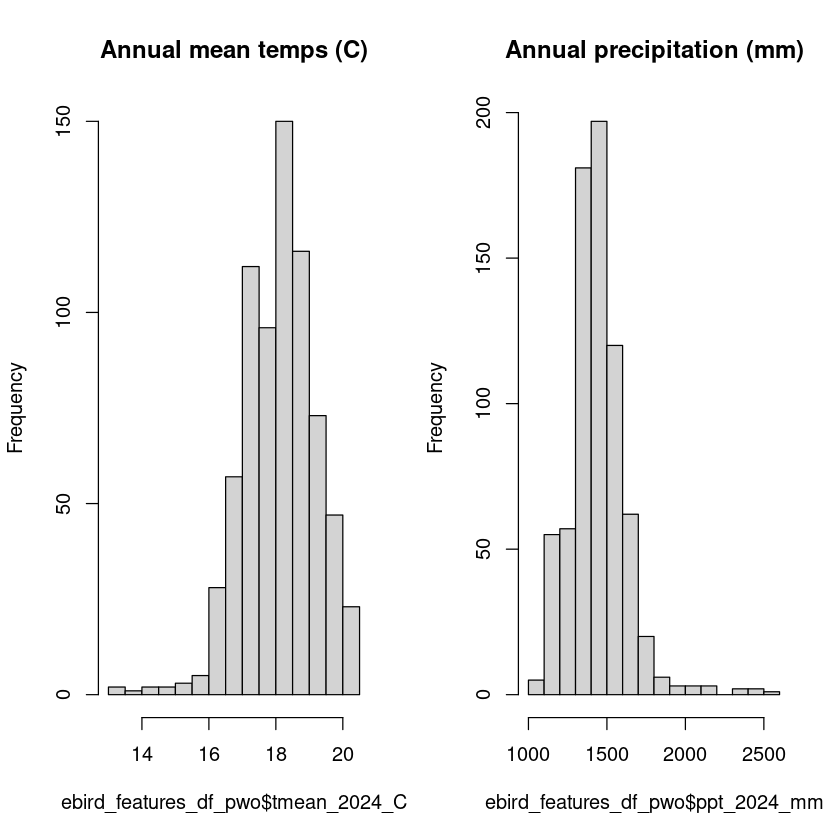

In [ ]:
par(mfrow = c(1, 2))
hist(ebird_features_df_pwo$tmean_2024_C, main = "Annual mean temps (C)")
hist(ebird_features_df_pwo$ppt_2024_mm, main = "Annual precipitation (mm)")

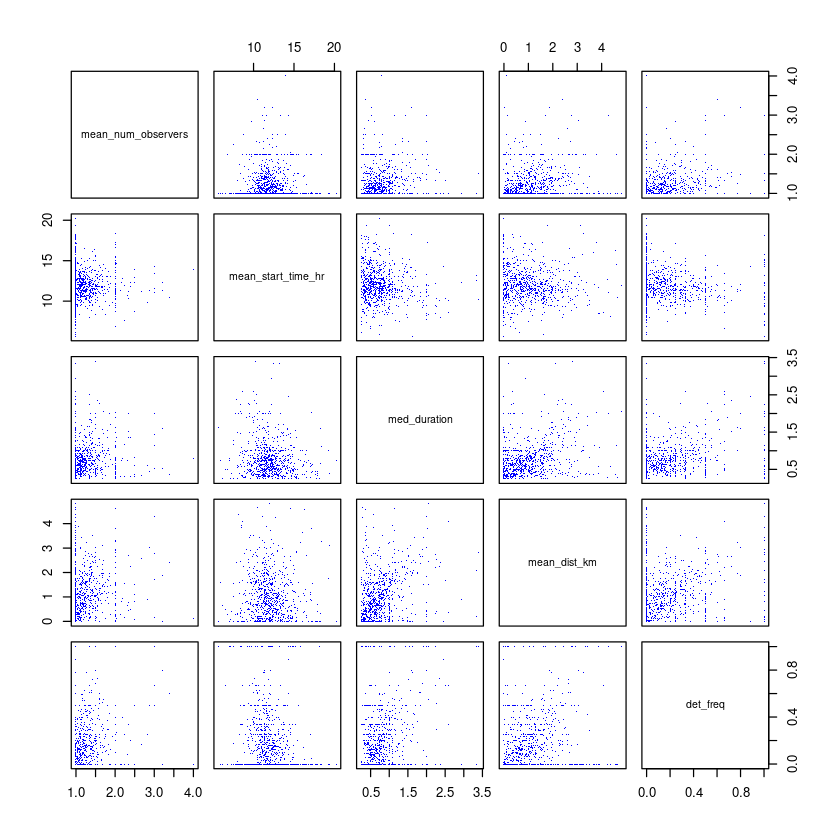

In [15]:
pairs(ebird_features_df_pwo[c(
        "mean_num_observers", "mean_start_time_hr", "med_duration", "mean_dist_km", "det_freq"
        )], pch = ".", col = "blue")

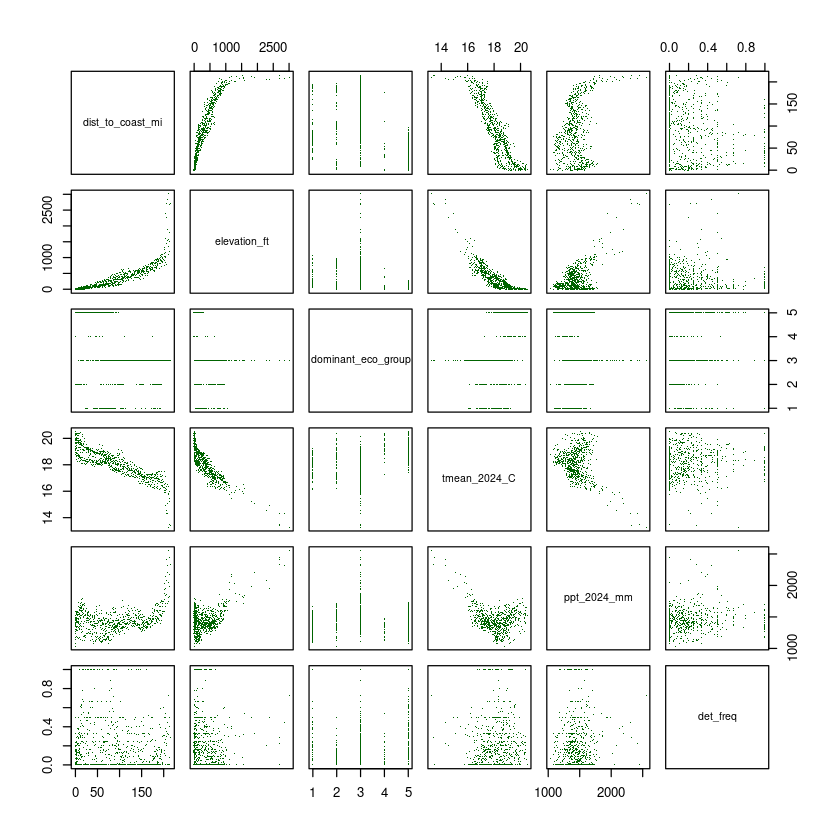

In [17]:
pairs(ebird_features_df_pwo[c(
        "dist_to_coast_mi", "elevation_ft", "dominant_eco_group",
        "tmean_2024_C", "ppt_2024_mm", "det_freq")], pch = ".", col = "darkgreen")

In [36]:
# Additive model with raw detection frequency as response
mod_add_pwo = lm(det_freq ~ mean_num_observers + mean_start_time_hr + med_duration + mean_dist_km +
                        dist_to_coast_mi + elevation_ft + dominant_eco_group +
                        tmean_2024_C + ppt_2024_mm,
                data = ebird_features_df_pwo, weight = n_checklists)
summary(mod_add_pwo)


Call:
lm(formula = det_freq ~ mean_num_observers + mean_start_time_hr + 
    med_duration + mean_dist_km + dist_to_coast_mi + elevation_ft + 
    dominant_eco_group + tmean_2024_C + ppt_2024_mm, data = ebird_features_df_pwo, 
    weights = n_checklists)

Weighted Residuals:
    Min      1Q  Median      3Q     Max 
-5.8729 -0.3368 -0.0607  0.4602  4.9362 

Coefficients:
                              Estimate Std. Error t value Pr(>|t|)    
(Intercept)                  2.977e-01  1.912e-01   1.557 0.119960    
mean_num_observers          -2.649e-02  2.482e-02  -1.067 0.286164    
mean_start_time_hr          -1.261e-02  3.763e-03  -3.351 0.000849 ***
med_duration                 1.132e-01  1.356e-02   8.343 3.82e-16 ***
mean_dist_km                 8.221e-02  7.838e-03  10.489  < 2e-16 ***
dist_to_coast_mi             1.667e-04  1.574e-04   1.059 0.289804    
elevation_ft                 6.648e-06  2.960e-05   0.225 0.822372    
dominant_eco_groupDeveloped -7.321e-02  2.618e-02  -2.796 0

In [69]:
get_k10_cv_rmse(formula(mod_add_pwo), ebird_features_df_pwo)

[1] 0.2333085


	Shapiro-Wilk normality test

data:  resid(mod_add_pwo)
W = 0.89824, p-value < 2.2e-16


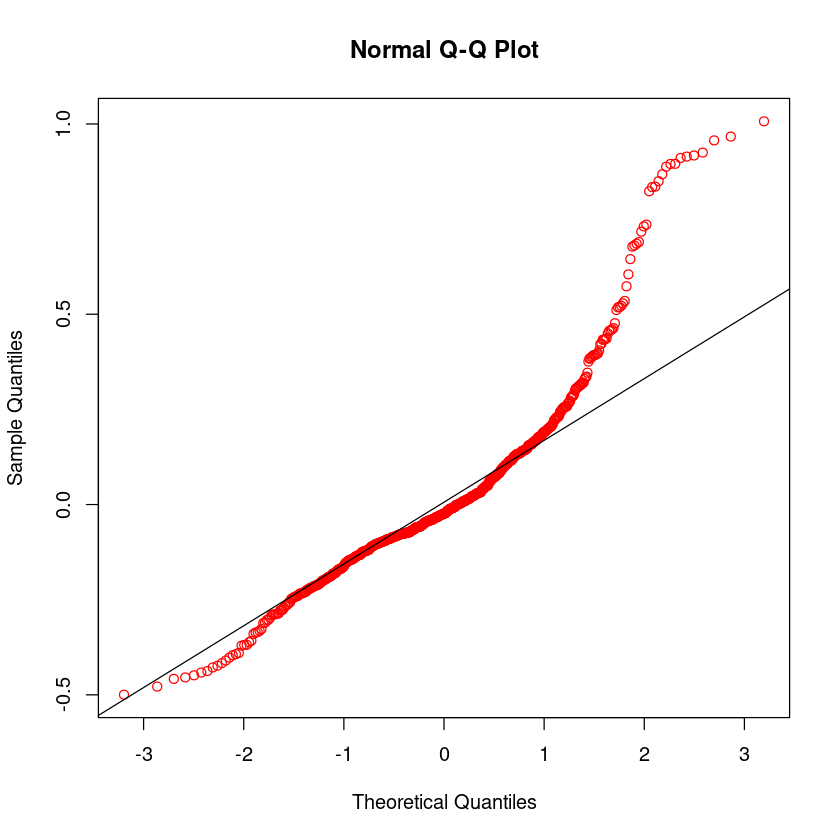

In [37]:
qqnorm(resid(mod_add_pwo), col = "red")
qqline(resid(mod_add_pwo))
shapiro.test(resid(mod_add_pwo))


	studentized Breusch-Pagan test

data:  mod_add_pwo
BP = 55010, df = 12, p-value < 2.2e-16


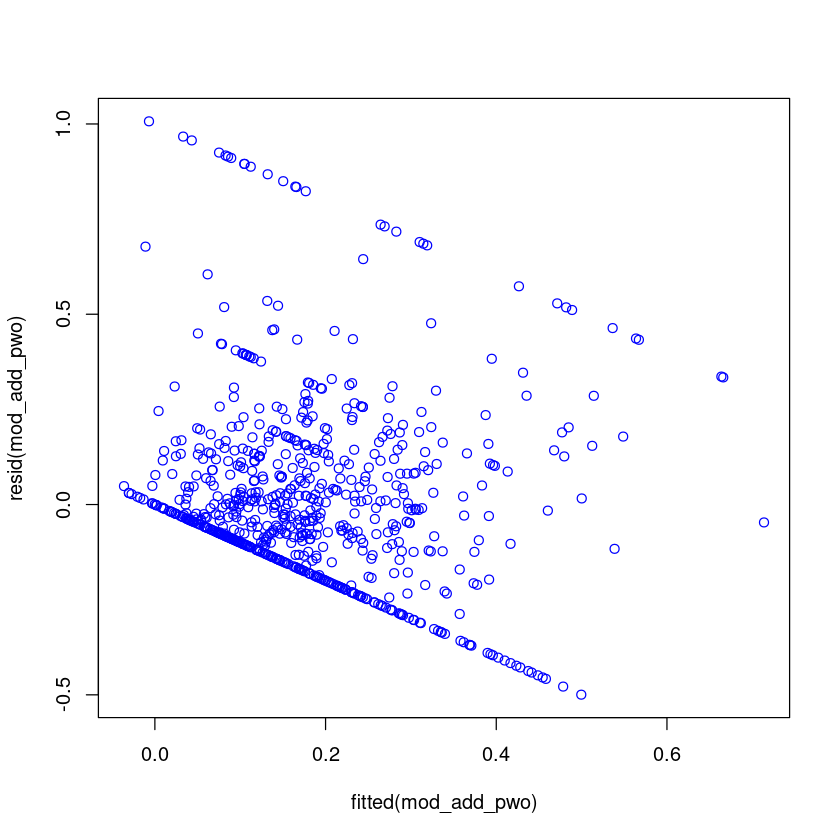

In [39]:
plot(resid(mod_add_pwo) ~ fitted(mod_add_pwo), col = "blue")
lmtest::bptest(mod_add_pwo)

In [25]:
# Using log(y+0.1) transformation. Used offset because there are some 0-detection cells.
mod_add_pwo_logy = lm(log(det_freq + 0.1) ~ (mean_num_observers + mean_start_time_hr + med_duration + mean_dist_km +
                        dist_to_coast_mi + elevation_ft + dominant_eco_group +
                        tmean_2024_C + ppt_2024_mm),
                data = ebird_features_df_pwo, weight = n_checklists)
summary(mod_add_pwo_logy)


Call:
lm(formula = log(det_freq + 0.1) ~ (mean_num_observers + mean_start_time_hr + 
    med_duration + mean_dist_km + dist_to_coast_mi + elevation_ft + 
    dominant_eco_group + tmean_2024_C + ppt_2024_mm), data = ebird_features_df_pwo, 
    weights = n_checklists)

Weighted Residuals:
     Min       1Q   Median       3Q      Max 
-21.1335  -1.3316  -0.2625   1.5555  14.2379 

Coefficients:
                              Estimate Std. Error t value Pr(>|t|)    
(Intercept)                 -2.9074057  0.6936501  -4.191 3.12e-05 ***
mean_num_observers          -0.0701050  0.0900222  -0.779 0.436387    
mean_start_time_hr          -0.0467404  0.0136506  -3.424 0.000653 ***
med_duration                 0.3021841  0.0492033   6.142 1.37e-09 ***
mean_dist_km                 0.2993085  0.0284306  10.528  < 2e-16 ***
dist_to_coast_mi             0.0013354  0.0005710   2.339 0.019618 *  
elevation_ft                 0.0002402  0.0001074   2.236 0.025635 *  
dominant_eco_groupDeveloped -0.22393


	Shapiro-Wilk normality test

data:  resid(mod_add_pwo_logy)
W = 0.99629, p-value = 0.09014


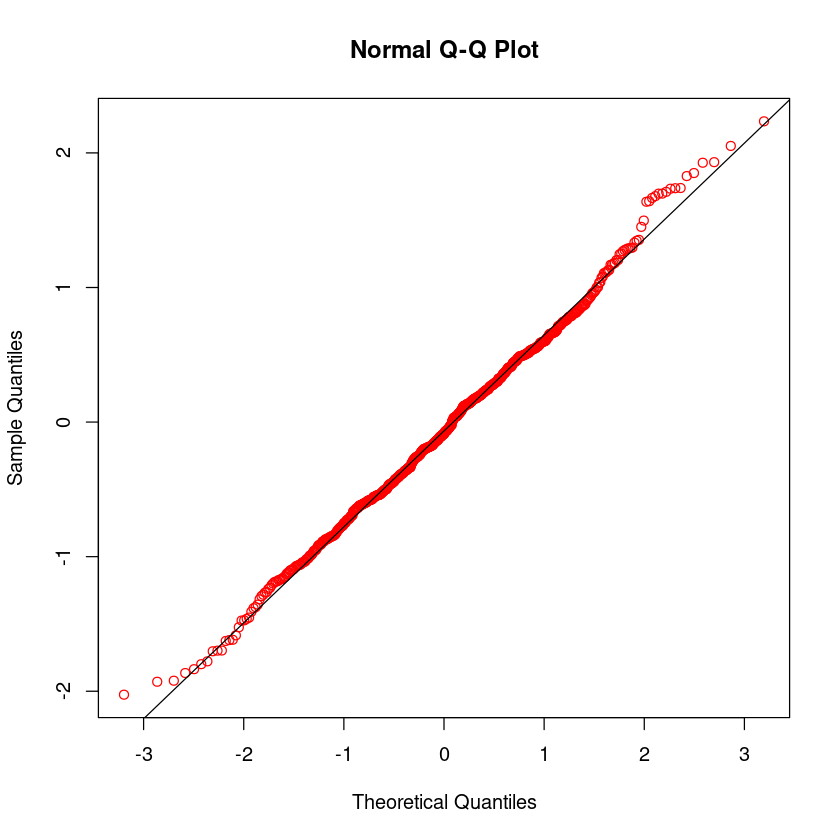

In [26]:
qqnorm(resid(mod_add_pwo_logy), col = "red")
qqline(resid(mod_add_pwo_logy))
shapiro.test(resid(mod_add_pwo_logy))


	studentized Breusch-Pagan test

data:  mod_add_pwo_logy
BP = 54099, df = 12, p-value < 2.2e-16


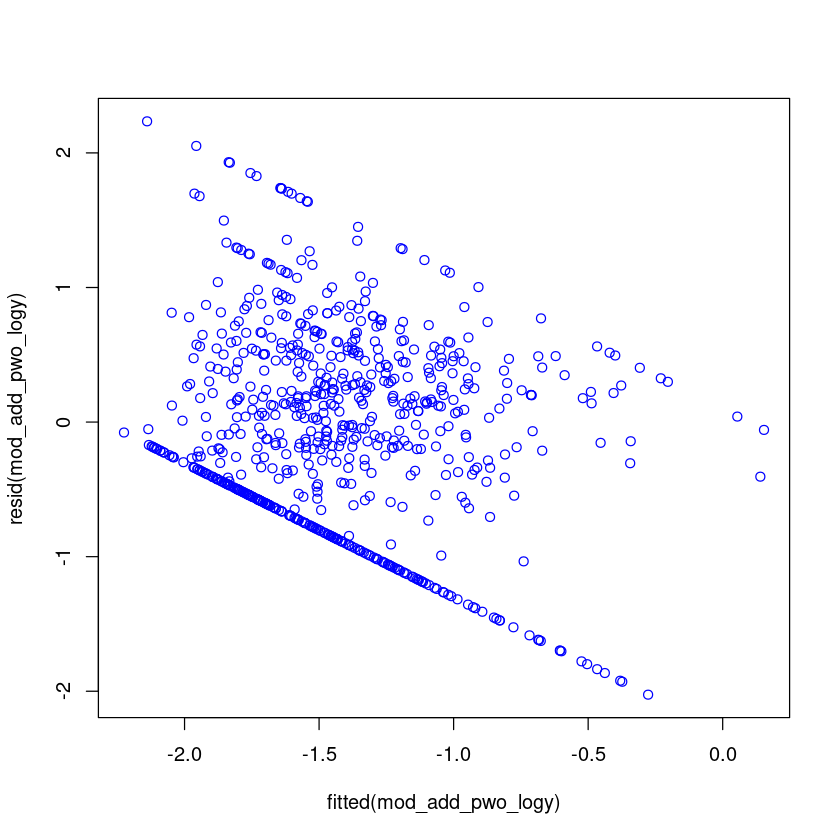

In [29]:
plot(resid(mod_add_pwo_logy) ~ fitted(mod_add_pwo_logy), col = "blue")
lmtest::bptest(mod_add_pwo_logy)

In [30]:
form_pwo_base = det_freq ~ 
                    (mean_num_observers + mean_start_time_hr + med_duration + mean_dist_km +
                     dist_to_coast_mi + elevation_ft + dominant_eco_group +
                     tmean_2024_C + ppt_2024_mm)
mod_pwo_glm_base = glm(form_pwo_base,
                 weights = n_checklists,
                 data = ebird_features_df_pwo,
                 family = binomial)
summary(mod_pwo_glm_base)


Call:
glm(formula = form_pwo_base, family = binomial, data = ebird_features_df_pwo, 
    weights = n_checklists)

Coefficients:
                              Estimate Std. Error z value Pr(>|z|)    
(Intercept)                 -1.721e+00  6.200e-01  -2.776  0.00551 ** 
mean_num_observers          -1.090e-01  7.527e-02  -1.448  0.14770    
mean_start_time_hr          -9.879e-02  1.237e-02  -7.987 1.39e-15 ***
med_duration                 6.542e-01  3.797e-02  17.230  < 2e-16 ***
mean_dist_km                 5.429e-01  2.306e-02  23.548  < 2e-16 ***
dist_to_coast_mi             2.231e-03  5.059e-04   4.411 1.03e-05 ***
elevation_ft                 1.309e-04  9.137e-05   1.433  0.15181    
dominant_eco_groupDeveloped -5.828e-01  7.989e-02  -7.295 2.99e-13 ***
dominant_eco_groupForest    -8.320e-02  7.845e-02  -1.061  0.28890    
dominant_eco_groupWater     -6.626e-01  9.128e-02  -7.259 3.91e-13 ***
dominant_eco_groupWetland    3.451e-01  8.267e-02   4.175 2.98e-05 ***
tmean_2024_C       


	Shapiro-Wilk normality test

data:  resid(mod_pwo_glm_base)
W = 0.91251, p-value < 2.2e-16


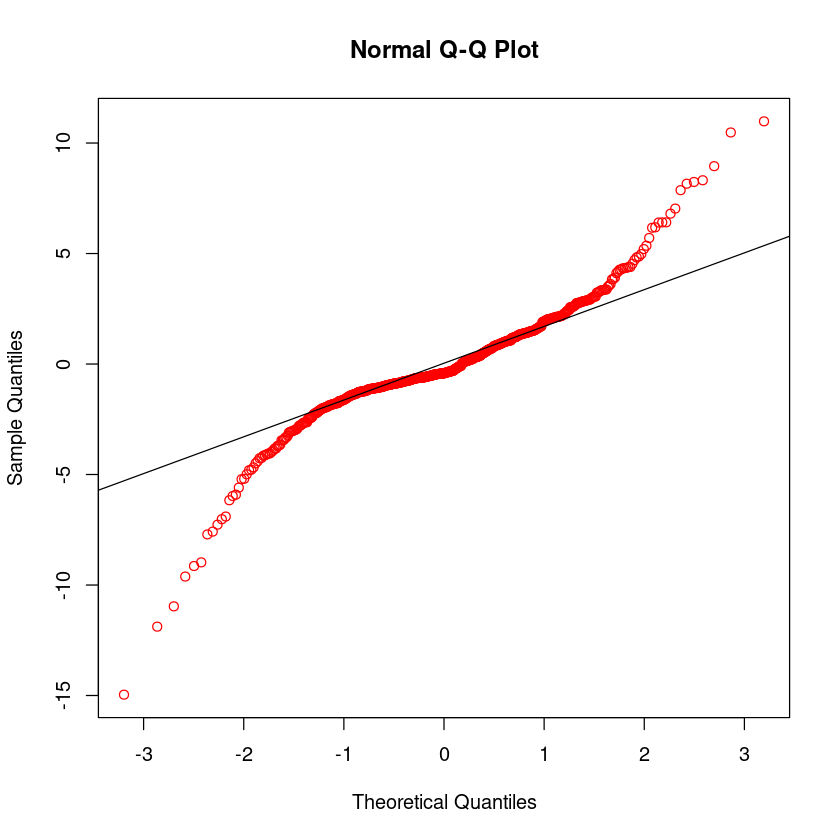

In [32]:
qqnorm(resid(mod_pwo_glm_base), col = "red")
qqline(resid(mod_pwo_glm_base))
shapiro.test(resid(mod_pwo_glm_base))


	studentized Breusch-Pagan test

data:  mod_pwo_glm_base
BP = 55010, df = 12, p-value < 2.2e-16


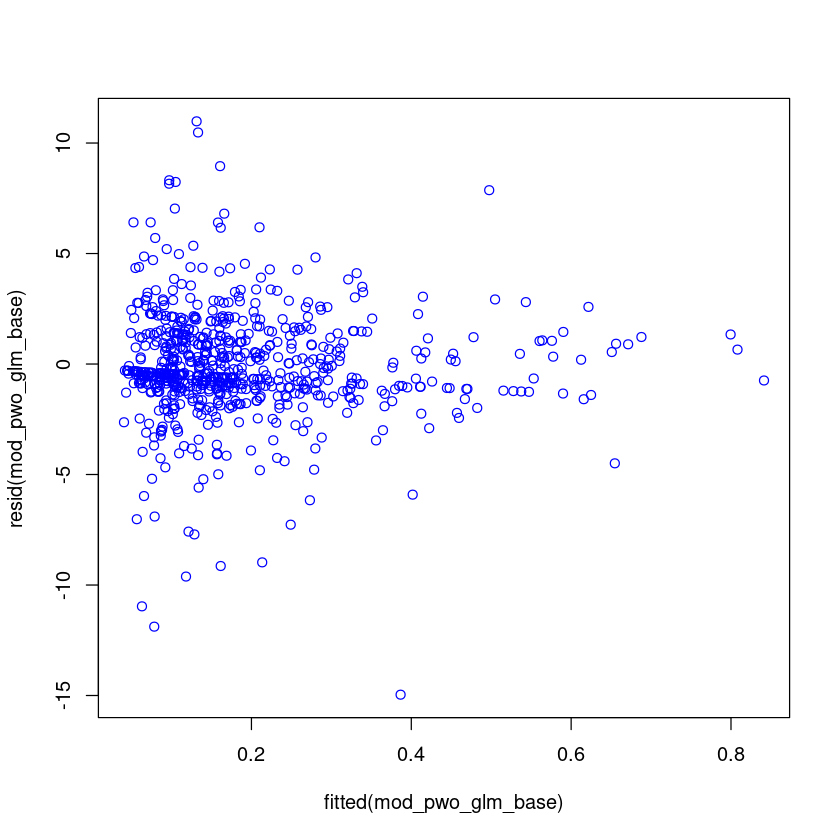

In [34]:
plot(resid(mod_pwo_glm_base) ~ fitted(mod_pwo_glm_base), col = "blue")
lmtest::bptest(mod_pwo_glm_base)

In [41]:
# full poly model
form_pwo_glm_full_poly = det_freq ~ (mean_num_observers + mean_start_time_hr + med_duration + mean_dist_km +
                                     I(mean_dist_km^2)+I(mean_dist_km^3) +
                                     dist_to_coast_mi +
                                     I(dist_to_coast_mi^2)+I(dist_to_coast_mi^3) +
                                     elevation_ft +
                                     I(elevation_ft^2) +
                                     dominant_eco_group + tmean_2024_C + ppt_2024_mm)
mod_pwo_glm_full_poly = glm(form_pwo_glm_full_poly,
                            weights = n_checklists,
                            data = ebird_features_df_pwo,
                            family = binomial)
summary(mod_pwo_glm_full_poly)


Call:
glm(formula = form_pwo_glm_full_poly, family = binomial, data = ebird_features_df_pwo, 
    weights = n_checklists)

Coefficients:
                              Estimate Std. Error z value Pr(>|z|)    
(Intercept)                 -3.489e+00  6.452e-01  -5.408 6.37e-08 ***
mean_num_observers          -1.624e-02  7.605e-02  -0.214 0.830892    
mean_start_time_hr          -1.421e-01  1.302e-02 -10.917  < 2e-16 ***
med_duration                 7.869e-01  4.128e-02  19.064  < 2e-16 ***
mean_dist_km                 1.507e+00  1.388e-01  10.862  < 2e-16 ***
I(mean_dist_km^2)           -6.352e-01  9.706e-02  -6.544 5.99e-11 ***
I(mean_dist_km^3)            9.497e-02  1.901e-02   4.995 5.90e-07 ***
dist_to_coast_mi             4.698e-02  2.112e-03  22.248  < 2e-16 ***
I(dist_to_coast_mi^2)       -5.099e-04  2.888e-05 -17.653  < 2e-16 ***
I(dist_to_coast_mi^3)        1.604e-06  9.835e-08  16.308  < 2e-16 ***
elevation_ft                -1.240e-03  2.328e-04  -5.325 1.01e-07 ***
I(elevatio

In [44]:
set.seed(42)
get_k10_cv_rmse_glm(form_pwo_glm_full_poly, ebird_features_df_pwo)

[1] 0.2275968

In [45]:
anova(mod_pwo_glm_base, mod_pwo_glm_full_poly)

,Resid. Df,Resid. Dev,Df,Deviance,Pr(>Chi)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,704,4218.106,NA,NA,NA
2,699,3549.905,5,668.201,3.682344e-142


In [46]:
n = nrow(ebird_features_df_pwo)
best_bic_mod_pwo_glm_poly = step(mod_pwo_glm_full_poly, direction = "backward", k = log(n), trace = FALSE)
summary(best_bic_mod_pwo_glm_poly)


Call:
glm(formula = det_freq ~ mean_start_time_hr + med_duration + 
    mean_dist_km + I(mean_dist_km^2) + I(mean_dist_km^3) + dist_to_coast_mi + 
    I(dist_to_coast_mi^2) + I(dist_to_coast_mi^3) + elevation_ft + 
    I(elevation_ft^2) + dominant_eco_group, family = binomial, 
    data = ebird_features_df_pwo, weights = n_checklists)

Coefficients:
                              Estimate Std. Error z value Pr(>|z|)    
(Intercept)                 -2.094e+00  1.865e-01 -11.226  < 2e-16 ***
mean_start_time_hr          -1.421e-01  1.300e-02 -10.930  < 2e-16 ***
med_duration                 7.842e-01  4.108e-02  19.091  < 2e-16 ***
mean_dist_km                 1.527e+00  1.381e-01  11.060  < 2e-16 ***
I(mean_dist_km^2)           -6.433e-01  9.681e-02  -6.645 3.04e-11 ***
I(mean_dist_km^3)            9.585e-02  1.894e-02   5.060 4.19e-07 ***
dist_to_coast_mi             4.568e-02  2.031e-03  22.487  < 2e-16 ***
I(dist_to_coast_mi^2)       -5.035e-04  2.868e-05 -17.556  < 2e-16 ***
I(dist_t

In [ ]:
set.seed(42)
get_k10_cv_rmse_glm(form_pwo_base, ebird_features_df_pwo)
get_k10_cv_rmse_glm(form_pwo_glm_full_poly, ebird_features_df_pwo)
get_k10_cv_rmse_glm(formula(best_bic_mod_pwo_glm_poly), ebird_features_df_pwo)

[1] 0.2324004

[1] 0.2275968

[1] 0.2276061

In [49]:
anova(mod_pwo_glm_base, best_bic_mod_pwo_glm_poly)
anova(best_bic_mod_pwo_glm_poly, mod_pwo_glm_full_poly)

,Resid. Df,Resid. Dev,Df,Deviance,Pr(>Chi)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,704,4218.106,NA,NA,NA
2,702,3557.731,2,660.3744,3.995031e-144


,Resid. Df,Resid. Dev,Df,Deviance,Pr(>Chi)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,702,3557.731,NA,NA,NA
2,699,3549.905,3,7.826596,0.04973475


In [51]:
# poly and curated interactive model 2
# Based on what interaction terms seem the most signficant in first curated-interaction model
form_pwo_glm_poly_cint3 = det_freq ~ (mean_num_observers + mean_start_time_hr + med_duration +
                                      mean_dist_km + I(mean_dist_km^2) + I(mean_dist_km^3) +
                                           mean_num_observers:mean_start_time_hr +
                                           mean_num_observers:mean_dist_km +
                                           mean_start_time_hr:mean_dist_km +
                                           mean_start_time_hr:I(mean_dist_km^2) +
                                           mean_start_time_hr:I(mean_dist_km^3) + 
                                           med_duration:mean_dist_km + 
                                           med_duration:I(mean_dist_km^2) +
                                           med_duration:I(mean_dist_km^3) +
                                           dominant_eco_group + 
                                           dist_to_coast_mi + I(dist_to_coast_mi^2) + I(dist_to_coast_mi^3) + 
                                           elevation_ft + I(elevation_ft^2) +
                                           tmean_2024_C +
                                           ppt_2024_mm + 
                                           dist_to_coast_mi:ppt_2024_mm + 
                                           I(dist_to_coast_mi^2):ppt_2024_mm + 
                                           I(dist_to_coast_mi^3):ppt_2024_mm
                                           )
mod_pwo_glm_poly_cint3 = glm(form_pwo_glm_poly_cint3,
                            weights = n_checklists,
                            data = ebird_features_df_pwo,
                            family = binomial)
summary(mod_pwo_glm_poly_cint3)


Call:
glm(formula = form_pwo_glm_poly_cint3, family = binomial, data = ebird_features_df_pwo, 
    weights = n_checklists)

Coefficients:
                                        Estimate Std. Error z value Pr(>|z|)
(Intercept)                            1.882e+00  1.104e+00   1.705 0.088281
mean_num_observers                    -4.817e+00  6.948e-01  -6.933 4.12e-12
mean_start_time_hr                    -4.485e-01  7.189e-02  -6.239 4.41e-10
med_duration                          -7.342e-02  1.326e-01  -0.554 0.579793
mean_dist_km                           4.242e+00  1.185e+00   3.579 0.000345
I(mean_dist_km^2)                     -2.356e+00  8.803e-01  -2.676 0.007442
I(mean_dist_km^3)                      3.859e-01  1.737e-01   2.222 0.026302
dominant_eco_groupDeveloped           -5.990e-01  8.553e-02  -7.004 2.50e-12
dominant_eco_groupForest              -8.084e-02  8.504e-02  -0.951 0.341795
dominant_eco_groupWater               -6.011e-01  9.696e-02  -6.199 5.67e-10
dominant_eco_g

In [62]:
n = nrow(ebird_features_df_pwo)
best_bic_mod_pwo_glm_poly_cint3 = step(mod_pwo_glm_poly_cint3, direction = "backward", k = log(n), trace = FALSE)
summary(best_bic_mod_pwo_glm_poly_cint3)


Call:
glm(formula = det_freq ~ mean_num_observers + mean_start_time_hr + 
    med_duration + mean_dist_km + I(mean_dist_km^2) + I(mean_dist_km^3) + 
    dominant_eco_group + dist_to_coast_mi + I(dist_to_coast_mi^2) + 
    I(dist_to_coast_mi^3) + elevation_ft + I(elevation_ft^2) + 
    ppt_2024_mm + mean_num_observers:mean_start_time_hr + mean_start_time_hr:mean_dist_km + 
    med_duration:mean_dist_km + med_duration:I(mean_dist_km^2) + 
    med_duration:I(mean_dist_km^3) + dist_to_coast_mi:ppt_2024_mm + 
    I(dist_to_coast_mi^2):ppt_2024_mm + I(dist_to_coast_mi^3):ppt_2024_mm, 
    family = binomial, data = ebird_features_df_pwo, weights = n_checklists)

Coefficients:
                                        Estimate Std. Error z value Pr(>|z|)
(Intercept)                            2.650e+00  8.426e-01   3.145 0.001661
mean_num_observers                    -4.484e+00  6.446e-01  -6.956 3.50e-12
mean_start_time_hr                    -5.083e-01  6.473e-02  -7.853 4.08e-15
med_duration 

In [60]:
setdiff(names(coef(mod_pwo_glm_poly_cint3)), names(coef(best_bic_mod_pwo_glm_poly_cint3)))

[1] "tmean_2024_C"                        
[2] "mean_num_observers:mean_dist_km"     
[3] "mean_start_time_hr:I(mean_dist_km^2)"
[4] "mean_start_time_hr:I(mean_dist_km^3)"

In [63]:
set.seed(42)
get_k10_cv_rmse_glm(form_pwo_base, ebird_features_df_pwo)
get_k10_cv_rmse_glm(form_pwo_glm_full_poly, ebird_features_df_pwo)
get_k10_cv_rmse_glm(formula(best_bic_mod_pwo_glm_poly), ebird_features_df_pwo)
get_k10_cv_rmse_glm(form_pwo_glm_poly_cint3, ebird_features_df_pwo)
get_k10_cv_rmse_glm(formula(best_bic_mod_pwo_glm_poly_cint3), ebird_features_df_pwo)

[1] 0.2324004

[1] 0.2290311

[1] 0.2313498

[1] 0.235543

[1] 0.228568

In [ ]:
anova(best_bic_mod_pwo_glm_poly_cint3, mod_pwo_glm_poly_cint3)

In [ ]:
anova(best_bic_mod_pwo_glm_poly, best_bic_mod_pwo_glm_poly_cint3)

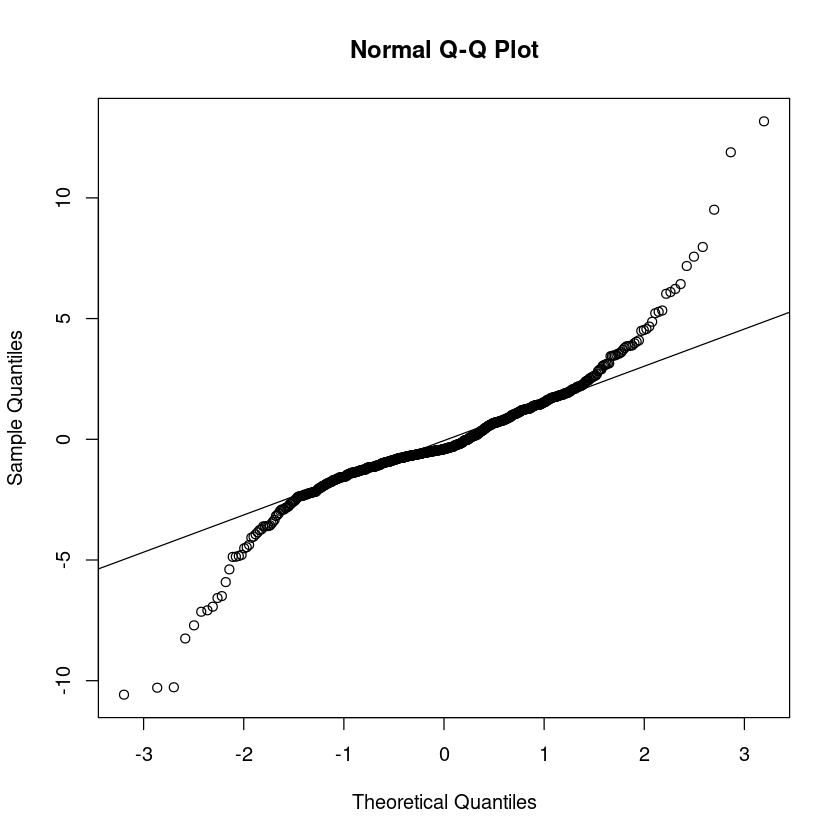

In [ ]:
qqnorm(resid(best_bic_mod_pwo_glm_poly_cint3), col = "red")
qqline(resid(best_bic_mod_pwo_glm_poly_cint3))

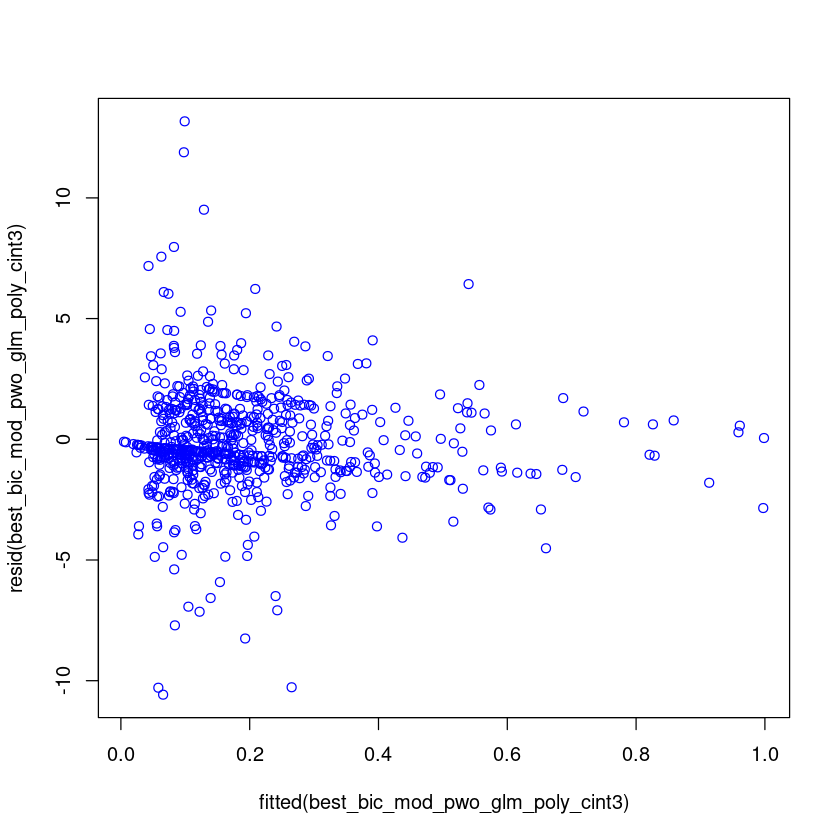

In [65]:
plot(resid(best_bic_mod_pwo_glm_poly_cint3) ~ fitted(best_bic_mod_pwo_glm_poly_cint3), col = "blue")


# Collinearity

In [ ]:
cor(select(ebird_features_df_pwo, mean_num_observers, mean_start_time_hr, med_duration, mean_dist_km,
                        dist_to_coast_mi, elevation_ft,
                        tmean_2024_C, ppt_2024_mm, det_freq))

In [ ]:
car::vif(mod_pwo_glm_base)

# Appendix

In [71]:
get_percent_high_leverage = function(df, model) {
    n = nrow(df)
    p = length(coef(model))
    h_mean = p / n
    nrow(df[hatvalues(model) > 2*h_mean,]) / n
}

get_percent_outliers = function(df, model) {
    n = nrow(df)
    sum(abs(rstandard(model)) > 2) / n
}

get_percent_high_cooks_distance = function(df, model) {
    n = nrow(df)
    nrow(df[cooks.distance(model) > 4/n,]) / n
}

get_k10_cv_rmse = function(formula, df) {
    train_control_k10 <- caret::trainControl(method = "cv", number = 10)
    mod_add_pwo_cv_fit <- caret::train(
        form = formula,
        data = df,
        weights = n_checklists,
        method = "lm",
        trControl = train_control_k10
     )
     mod_add_pwo_cv_fit$results[1,"RMSE"]
}

get_k10_cv_rmse_logy = function(formula, df) {
    train_control_k10 <- caret::trainControl(method = "cv", number = 10, savePredictions = "final")
    mod_add_pwo_logy_cv_fit <- caret::train(
        form = formula,
        data = df,
        weights = n_checklists,
        method = "lm",
        trControl = train_control_k10
    )

    # RMSE on original detection-frequency scale
    preds <- mod_add_pwo_logy_cv_fit$pred
    preds$pred_original <- exp(preds$pred)-0.1
    preds$obs_original  <- exp(preds$obs)-0.1

    rmse_original <- sqrt(mean((preds$obs_original - preds$pred_original)^2))
    rmse_original
    # ChatGPT helped with this.
}


get_k10_cv_rmse_glm = function(formula, df) {
    train_control_k10 <- caret::trainControl(method = "cv", number = 10, savePredictions = "final")
    glm_mod_cv_fit <- caret::train(
        form = formula,
        data = df,
        method = "glm",
        family = binomial(),
        weights = n_checklists,
        trControl = train_control_k10
    )
    # RMSE on original detection-frequency scale
    preds <- glm_mod_cv_fit$pred
    sqrt(mean((preds$obs - preds$pred)^2)) # This is back in probability space already
}

In [7]:
# eBird data structure
auk_extract = get_auk_extract("pileated_woodpecker_20251130.txt")
ebird_zf_df_filtered_pwo = zerofill_and_clean(auk_extract$ebd_only_df, auk_extract$sed_only_df)
str(ebird_zf_df_filtered_pwo)

tibble [56,168 × 47] (S3: tbl_df/tbl/data.frame)
 $ checklist_id             : chr [1:56168] "S166489286" "S192804519" "S160968636" "S204446437" ...
 $ last_edited_date         : chr [1:56168] "2025-08-22 06:35:57.831304" "2024-08-26 08:46:41.84928" "2025-08-24 20:59:57.935009" "2024-12-04 09:31:29.78307" ...
 $ country                  : chr [1:56168] "United States" "United States" "United States" "United States" ...
 $ country_code             : chr [1:56168] "US" "US" "US" "US" ...
 $ state                    : chr [1:56168] "South Carolina" "South Carolina" "South Carolina" "South Carolina" ...
 $ state_code               : chr [1:56168] "US-SC" "US-SC" "US-SC" "US-SC" ...
 $ county                   : chr [1:56168] "Aiken" "Aiken" "Aiken" "Aiken" ...
 $ county_code              : chr [1:56168] "US-SC-003" "US-SC-003" "US-SC-003" "US-SC-003" ...
 $ iba_code                 : chr [1:56168] NA NA NA NA ...
 $ bcr_code                 : int [1:56168] 27 27 27 27 27 27 27 27 27 27 ...

In [ ]:
str(ebird_zf_df_filtered_pwo)

In [ ]:
car::crPlots(mod_pwo_glm_base)

In [72]:
get_percent_high_leverage(ebird_features_df_pwo, mod_pwo_glm_base)
get_percent_outliers(ebird_features_df_pwo, mod_pwo_glm_base)
get_percent_high_cooks_distance(ebird_features_df_pwo, mod_pwo_glm_base)

[1] 0.1283124

[1] 0.2705718

[1] 0.2050209